In [9]:

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

tickers = ["AAPL", "MSFT", "JPM", "GS", "BLK"]

# Use the same historical period as Day 3.
data = yf.download(
    tickers,
    start="2025-09-22",
    end="2026-09-22",
    auto_adjust=True,
    progress=False
)

prices = data["Close"].dropna()

display(prices.head())
print("Number of trading days:", len(prices))

Ticker,AAPL,BLK,GS,JPM,MSFT
Date,,,,,
2025-09-22,255.137512,1112.436646,790.021606,306.575012,510.251892
2025-09-23,253.493591,1108.069824,790.766968,306.869354,505.074432
2025-09-24,251.381409,1104.378784,777.144897,307.536621,505.986877
2025-09-25,255.924637,1123.284790,779.429932,307.566071,502.892365
2025-09-26,254.519806,1132.253052,787.030457,310.127014,507.286194


Number of trading days: 251


In [10]:

# Daily stock returns
returns = prices.pct_change().dropna()

# Equal allocation across five stocks
weights = np.array([0.20, 0.20, 0.20, 0.20, 0.20])

# Daily returns for a daily-rebalanced portfolio
portfolio_returns = returns @ weights

display(portfolio_returns.head())

print(
    "Average daily portfolio return:",
    f"{portfolio_returns.mean():.4%}"
)

Date
2025-09-23   -0.003722
2025-09-24   -0.004982
2025-09-25    0.006422
2025-09-26    0.005862
2025-09-29    0.003894
dtype: float64

Average daily portfolio return: 0.0619%


In [11]:

# Growth of $1 invested
cumulative_growth = (1 + portfolio_returns).cumprod()

# Cumulative return in percentage terms
cumulative_returns = (cumulative_growth - 1) * 100

# Value of an initial $10,000 investment
initial_investment = 10000
portfolio_value = initial_investment * cumulative_growth

print(
    "Total cumulative return:",
    f"{cumulative_returns.iloc[-1]:.2f}%"
)

print(
    "Final portfolio value:",
    f"${portfolio_value.iloc[-1]:,.2f}"
)

display(portfolio_value.tail())

Total cumulative return: 14.84%
Final portfolio value: $11,484.41


Date
2026-09-15    11386.238087
2026-09-16    11202.999465
2026-09-17    11338.829929
2026-09-18    11328.693695
2026-09-21    11484.413661
dtype: float64

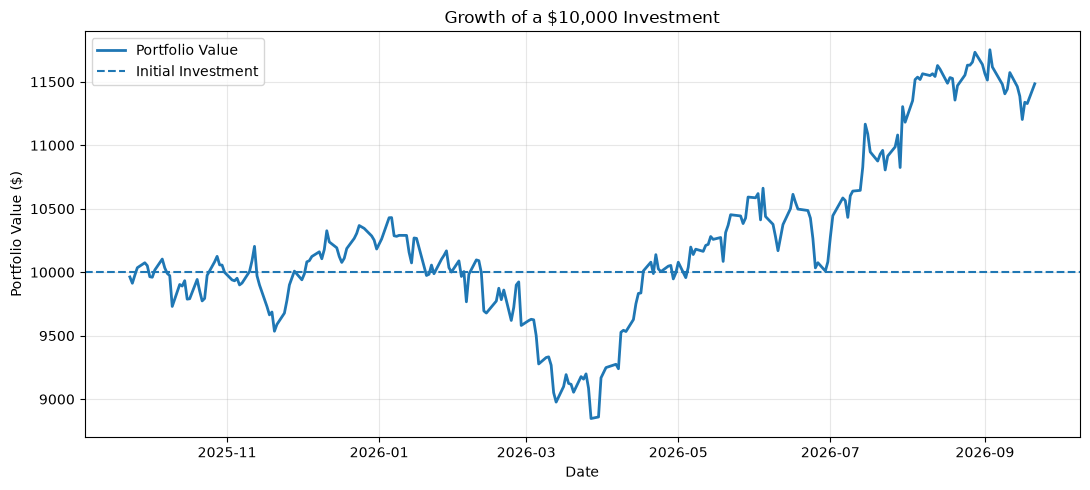

In [12]:

plt.figure(figsize=(11, 5))

plt.plot(
    portfolio_value.index,
    portfolio_value,
    linewidth=2,
    label="Portfolio Value"
)

plt.axhline(
    initial_investment,
    linestyle="--",
    label="Initial Investment"
)

plt.title("Growth of a $10,000 Investment")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:

trading_days = 252
risk_free_rate = 0.04

# Annualized arithmetic average return
annual_return = portfolio_returns.mean() * trading_days

# Annualized volatility
annual_volatility = (
    portfolio_returns.std() * np.sqrt(trading_days)
)

# Sharpe ratio
sharpe_ratio = (
    (annual_return - risk_free_rate)
    / annual_volatility
)

print(f"Annualized Return: {annual_return:.2%}")
print(f"Annualized Volatility: {annual_volatility:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

Annualized Return: 15.60%
Annualized Volatility: 18.20%
Sharpe Ratio: 0.64


In [14]:

# Highest portfolio value reached up to each date
running_peak = portfolio_value.cummax()

# Decline from the previous peak
drawdown = (
    portfolio_value / running_peak - 1
)

# Largest historical decline
max_drawdown = drawdown.min()

print(f"Maximum Drawdown: {max_drawdown:.2%}")

Maximum Drawdown: -15.17%


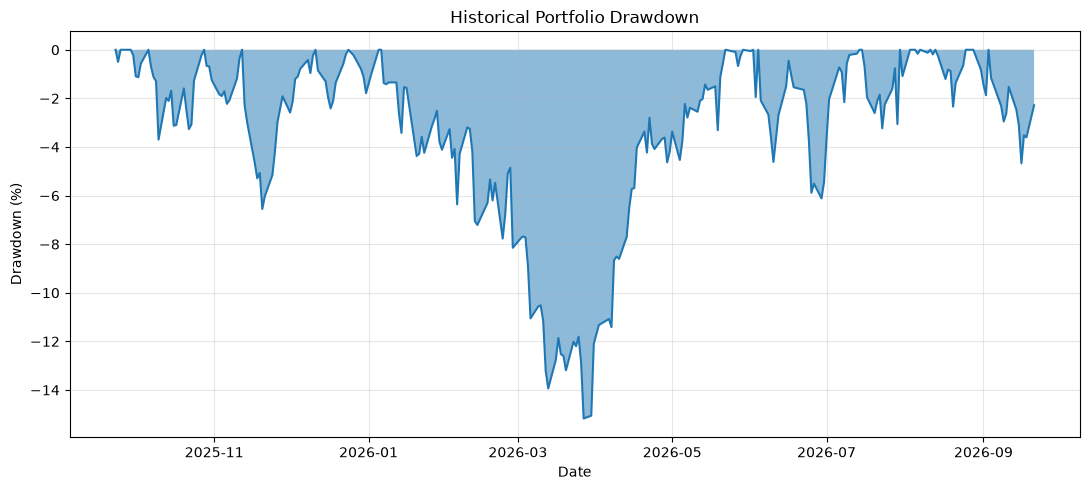

In [15]:

plt.figure(figsize=(11, 5))

plt.fill_between(
    drawdown.index,
    drawdown * 100,
    0,
    alpha=0.5
)

plt.plot(
    drawdown.index,
    drawdown * 100
)

plt.title("Historical Portfolio Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:

performance_summary = pd.DataFrame({
    "Metric": [
        "Cumulative Return",
        "Annualized Average Return",
        "Annualized Volatility",
        "Sharpe Ratio",
        "Maximum Drawdown",
        "Final Portfolio Value"
    ],
    "Value": [
        f"{cumulative_returns.iloc[-1]:.2f}%",
        f"{annual_return:.2%}",
        f"{annual_volatility:.2%}",
        f"{sharpe_ratio:.2f}",
        f"{max_drawdown:.2%}",
        f"${portfolio_value.iloc[-1]:,.2f}"
    ]
})

display(performance_summary)

,Metric,Value
0,Cumulative Return,14.84%
1,Annualized Average Return,15.60%
2,Annualized Volatility,18.20%
3,Sharpe Ratio,0.64
4,Maximum Drawdown,-15.17%
5,Final Portfolio Value,"$11,484.41"
